#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº5
#### Nicolas Bravo

## Introducción

En este trabajo se analizarán distintas señales de las cuales se tiene un único registro, debido a esto, se utilizará el método de Welch para estimar la densidad espectral de potencia. Este método consiste en dividir la señal en segmentos con solapamiento (en este trabajo se va a trabajar con un solapamiento del 50%) y se calcular cada periodograma para luego promediarlos entre sí, para así reducir la varianza del estimador con respecto al de un periodograma simple, a costa de tener una menor resolución espectral, ya que depende de la cantidad de muestras en cada segmento.

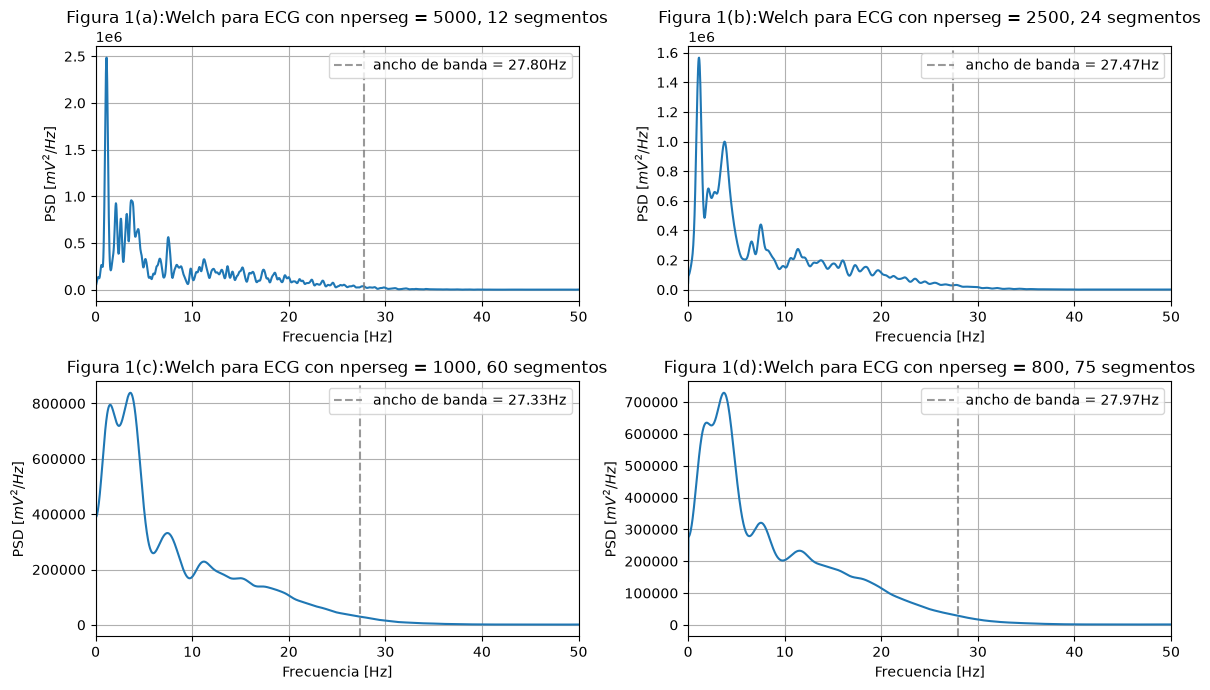

In [1]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio
from scipy.io.wavfile import write

def ancho_banda (frec, PSD, p):
    acum = np.cumsum(PSD)/np.sum(PSD)
    BW = frec[np.searchsorted(acum, 0.98)]
    return (BW)

p = 0.98

plt.close('all')
#%%
fs_ecg = 1000 # Hz

ecg_one_lead = np.load('ecg_sin_ruido.npy')

lenecg = len(ecg_one_lead)
#print(f"{lenecg}")

plt.figure(figsize=(12, 7))
plt.subplot(2,2,1)
nperseg = lenecg/6
frec_ecg, psd_ecg = sig.welch(ecg_one_lead, fs = fs_ecg, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenecg)
plt.xlim(0, 50)
plt.title(f"Figura 1(a):Welch para ECG con nperseg = {nperseg:.0f}, 12 segmentos")
plt.plot(frec_ecg, psd_ecg)
BW_ECG = ancho_banda(frec_ecg, psd_ecg, p = 0.98)
plt.axvline(BW_ECG, label = f'ancho de banda = {BW_ECG:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.grid()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.subplot(2,2,2)

nperseg = lenecg/12
frec_ecg, psd_ecg = sig.welch(ecg_one_lead, fs = fs_ecg, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenecg)
plt.xlim(0, 50)
plt.title(f"Figura 1(b):Welch para ECG con nperseg = {nperseg:.0f}, 24 segmentos")
plt.plot(frec_ecg, psd_ecg)
BW_ECG = ancho_banda(frec_ecg, psd_ecg, p = 0.98)
BW_ECG_fin = BW_ECG
plt.axvline(BW_ECG, label = f'ancho de banda = {BW_ECG:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.grid()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.subplot(2,2,3)

nperseg = lenecg/30
frec_ecg, psd_ecg = sig.welch(ecg_one_lead, fs = fs_ecg, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenecg)
plt.xlim(0, 50)
plt.title(f"Figura 1(c):Welch para ECG con nperseg = {nperseg:.0f}, 60 segmentos")
plt.plot(frec_ecg, psd_ecg)
BW_ECG = ancho_banda(frec_ecg, psd_ecg, p = 0.98)
plt.axvline(BW_ECG, label = f'ancho de banda = {BW_ECG:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.grid()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.subplot(2,2,4)

nperseg = lenecg/37.5
frec_ecg, psd_ecg = sig.welch(ecg_one_lead, fs = fs_ecg, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenecg)
plt.xlim(0, 50)
plt.title(f"Figura 1(d):Welch para ECG con nperseg = {nperseg:.0f}, 75 segmentos")
plt.plot(frec_ecg, psd_ecg)
BW_ECG = ancho_banda(frec_ecg, psd_ecg, p = 0.98)
plt.axvline(BW_ECG, label = f'ancho de banda = {BW_ECG:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.grid()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.tight_layout()

Analizando los cuatro gráficos de estimación se puede ver cómo afecta la cantidad de muestras en cada segmento del estimador de Welch. Al aumentar la cantidad de muestras por segmento (nperseg altos) el PSD va a tener una mayor resolución espectral y así permitiendo apreciar con mayor precisión la frecuencia fundamental y sus armónicos; sin embargo, esta mejoría en la resolución espectral tiene como consecuencia una mayor varianza debido a la poca cantidad de segmentos para promediar. En las estimaciones con pocas muestras por segmento se puede ver lo contrario: unas curvas más suaves gracias a la mayor cantidad de segmentos para promediar, pero la resolución espectral se reduce, produciendo picos más anchos que se fusionan entre si impidiendo distinguir la frecuencia fundamental de sus armónicos.
También se estimó el ancho de banda de la señal como la frecuencia por debajo de la cual se concentra el 98% de la potencia total. En los cuatro casos este estimador casi no varía, indicando que el estimador es robusto.

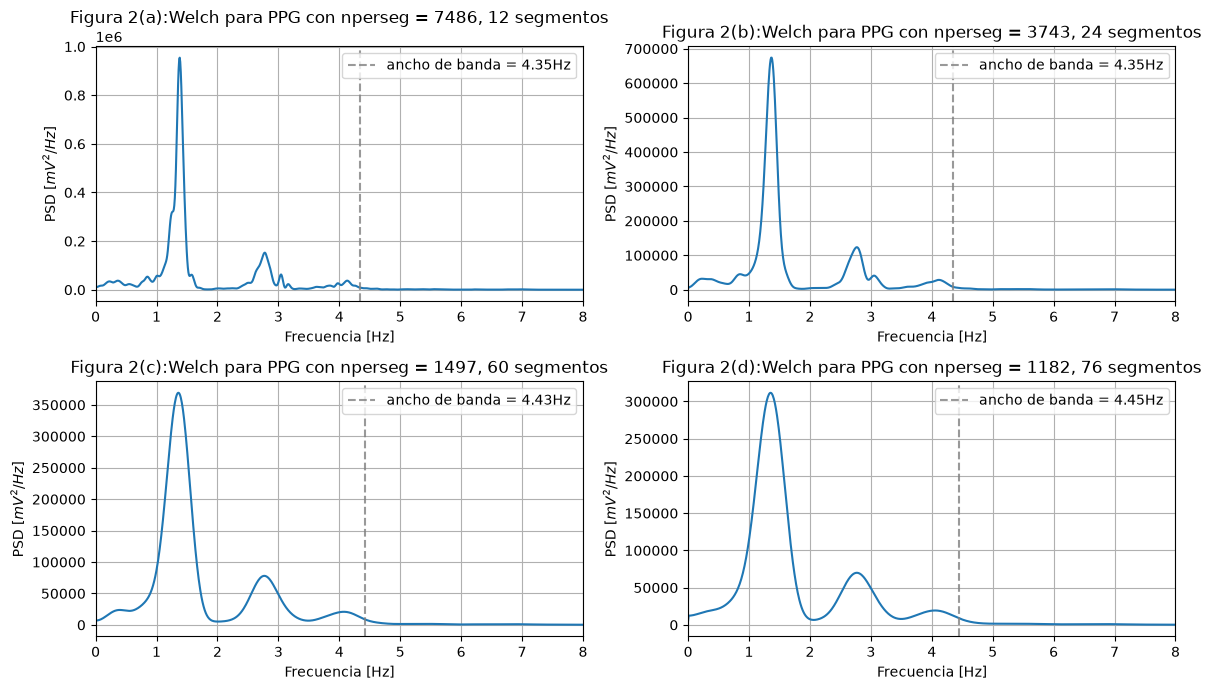

In [2]:
fs_ppg = 400 # Hz
ppg = np.load('ppg_sin_ruido.npy')

lenppg = len(ppg)

plt.figure(figsize=(12, 7))
nperseg = lenppg/6
frec_ppg, psd_ppg = sig.welch(ppg, fs = fs_ppg, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenppg)
plt.subplot(2,2,1)
plt.plot(frec_ppg, psd_ppg)
plt.xlim(0, 8)
BW_PPG = ancho_banda(frec_ppg, psd_ppg, p = 0.98)
plt.axvline(BW_PPG, label = f'ancho de banda = {BW_PPG:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.title(f"Figura 2(a):Welch para PPG con nperseg = {nperseg:.0f}, 12 segmentos")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.grid()

nperseg = lenppg/12
frec_ppg, psd_ppg = sig.welch(ppg, fs = fs_ppg, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenppg)
plt.subplot(2,2,2)
plt.plot(frec_ppg, psd_ppg)
plt.xlim(0, 8)
BW_PPG = ancho_banda(frec_ppg, psd_ppg, p = 0.98)
BW_PPG_fin = BW_PPG
plt.axvline(BW_PPG, label = f'ancho de banda = {BW_PPG:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.title(f"Figura 2(b):Welch para PPG con nperseg = {nperseg:.0f}, 24 segmentos")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.grid()

nperseg = lenppg/30
frec_ppg, psd_ppg = sig.welch(ppg, fs = fs_ppg, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenppg)
plt.subplot(2,2,3)
plt.plot(frec_ppg, psd_ppg)
plt.xlim(0, 8)
BW_PPG = ancho_banda(frec_ppg, psd_ppg, p = 0.98)
plt.axvline(BW_PPG, label = f'ancho de banda = {BW_PPG:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.title(f"Figura 2(c):Welch para PPG con nperseg = {nperseg:.0f}, 60 segmentos")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.grid()

nperseg = lenppg/38
frec_ppg, psd_ppg = sig.welch(ppg, fs = fs_ppg, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenppg)
plt.subplot(2,2,4)
plt.plot(frec_ppg, psd_ppg)
plt.xlim(0, 8)
BW_PPG = ancho_banda(frec_ppg, psd_ppg, p = 0.98)
plt.axvline(BW_PPG, label = f'ancho de banda = {BW_PPG:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.title(f"Figura 2(d):Welch para PPG con nperseg = {nperseg:.0f}, 76 segmentos")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.grid()
plt.tight_layout()

Partiendo de los anchos de banda estimados se puede ver como el ancho de banda del PPG (aproximadamente 5Hz) es mucho menor que el del ECG (aproximadamente 27Hz), lo cual permite utilizar un fs mucho menor para el análisis de un PPG según el criterio de Nyquist.

Text(0.5, 1.0, "Figura 5: Audio 'silbido' nperseg = 6000, 48 segmentos")

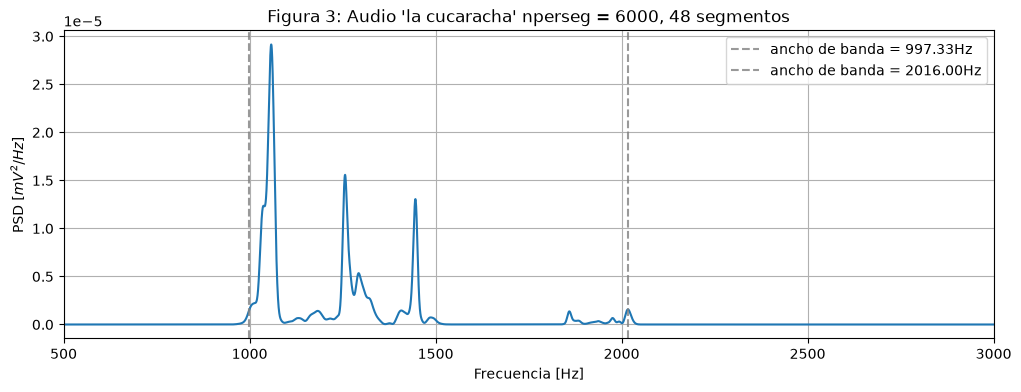

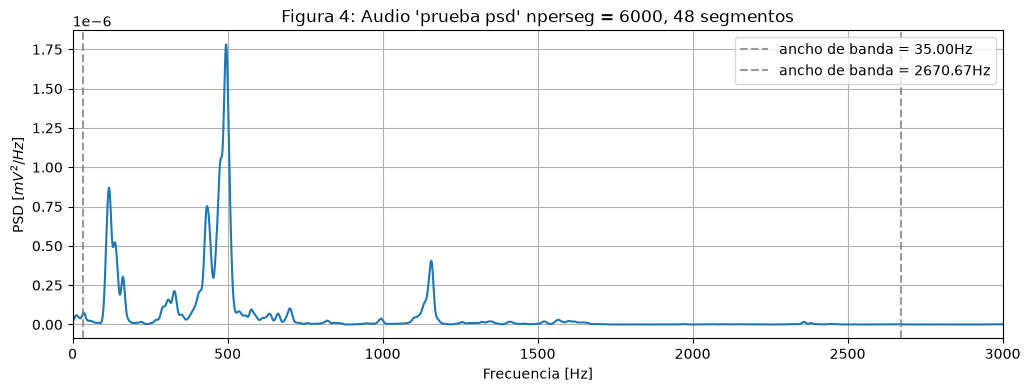

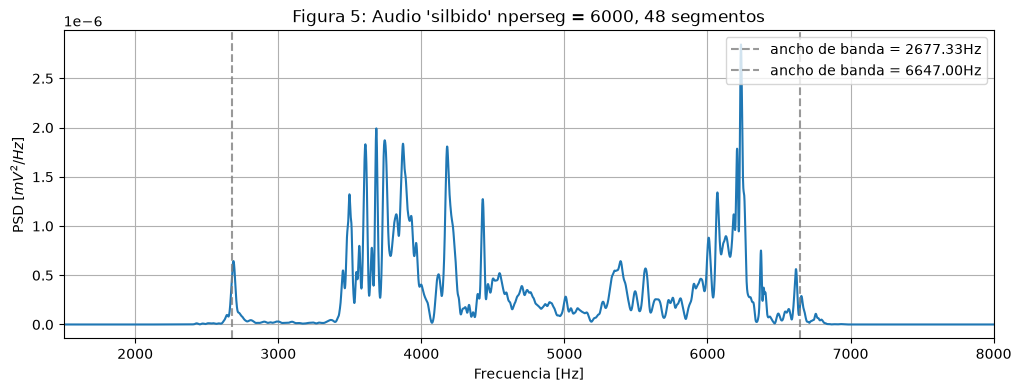

In [6]:
def ancho_banda_media (frec, PSD, p):
    acum = np.cumsum(PSD)/np.sum(PSD)
    f_baja = frec[np.searchsorted(acum, (1-p)/2)]
    f_alta = frec[np.searchsorted(acum, 1-(1-p)/2)]
    BW = f_alta - f_baja
    return(f_baja, f_alta, BW)

fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
plt.figure(figsize=(12, 4))
lenwav = len(wav_data)
nperseg = lenwav/24
frec_audio, psd_audio = sig.welch(wav_data, fs = fs_audio, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenwav)
plt.plot(frec_audio, psd_audio)
frec_baja_cuc, frec_alta_cuc, BW_cuc = ancho_banda_media(frec_audio, psd_audio, p = p)
plt.axvline(frec_baja_cuc, label = f'ancho de banda = {frec_baja_cuc:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.axvline(frec_alta_cuc, label = f'ancho de banda = {frec_alta_cuc:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.grid()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.title(f"Figura 3: Audio 'la cucaracha' nperseg = {nperseg:.0f}, 48 segmentos")
plt.xlim(500, 3000)
#%%

fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')
plt.figure(figsize=(12, 4))
lenwav = len(wav_data)
nperseg = lenwav/24
frec_audio, psd_audio = sig.welch(wav_data, fs = fs_audio, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenwav)
plt.plot(frec_audio, psd_audio)
frec_baja_prueb, frec_alta_prueb, BW_prueb = ancho_banda_media(frec_audio, psd_audio, p = p)
plt.axvline(frec_baja_prueb, label = f'ancho de banda = {frec_baja_prueb:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.axvline(frec_alta_prueb, label = f'ancho de banda = {frec_alta_prueb:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.xlim(0, 3000)
plt.grid()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.title(f"Figura 4: Audio 'prueba psd' nperseg = {nperseg:.0f}, 48 segmentos")
#%%

fs_audio, wav_data = sio.wavfile.read('silbido.wav')
plt.figure(figsize=(12, 4))
lenwav = len(wav_data)
nperseg = lenwav/24
frec_audio, psd_audio = sig.welch(wav_data, fs = fs_audio, nperseg = nperseg, noverlap = nperseg//2, detrend='linear', nfft = lenwav)
plt.plot(frec_audio, psd_audio)
frec_baja_silb, frec_alta_silb, BW_silb = ancho_banda_media(frec_audio, psd_audio, p = p)
plt.axvline(frec_baja_silb, label = f'ancho de banda = {frec_baja_silb:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.axvline(frec_alta_silb, label = f'ancho de banda = {frec_alta_silb:.2f}Hz', alpha = 0.8, linestyle = '--', color = 'grey')
plt.legend(loc = 'upper right')
plt.xlim(1500, 8000)
plt.grid()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD $[mV^2/Hz]$")
plt.title(f"Figura 5: Audio 'silbido' nperseg = {nperseg:.0f}, 48 segmentos")

A diferencia de los casos anteriores, la energía de las señales de audio se encuentra entre dos frecuencias específicas y no desde el origen. En el caso de la figura 4 las frecuencias se encuentran entre los 35 Hz y los 2670 Hz sin embargo, analizando el PSD se observa que pasando los 1250 Hz la señal se reduce a un piso de ruido, haciendo que el límite superior del ancho de banda aumente. Por otra parte, analizando las figuras 3 y 5 (las cuales son silbidos) la energía se concentra en frecuencias más altas.

In [4]:
print("Estimadores de ancho de banda")
print(f'{"Señal":<{10}} | {"f baja [Hz]":^{12}} | {"f alta [Hz]":^{12}} | {"ancho de banda [Hz]":^{12}}')
print(f'{"ECG":<{10}} | {"0":^{12}} | {BW_ECG_fin:^{12}.2f} | {BW_ECG_fin:^{12}.2f}')
print(f'{"PPG":<{10}} | {"0":^{12}} | {BW_PPG_fin:^{12}.2f} | {BW_PPG_fin:^{12}.2f}')
print(f'{"Canción":<{10}} | {frec_baja_cuc:^{12}.2f} | {frec_alta_cuc:^{12}.2f} | {BW_cuc:^{12}.2f}')
print(f'{"Frase":<{10}} | {frec_baja_prueb:^{12}.2f} | {frec_alta_prueb:^{12}.2f} | {BW_prueb:^{12}.2f}')
print(f'{"Silbido":<{10}} | {frec_baja_silb:^{12}.2f} | {frec_alta_silb:^{12}.2f} | {BW_silb:^{12}.2f}')

Estimadores de ancho de banda
Señal      | f baja [Hz]  | f alta [Hz]  | ancho de banda [Hz]
ECG        |      0       |    27.47     |    27.47    
PPG        |      0       |     4.35     |     4.35    
Canción    |    997.33    |   2016.00    |   1018.67   
Frase      |    35.00     |   2670.67    |   2635.67   
Silbido    |   2677.33    |   6647.00    |   3969.67   


Viendo la estimación del ancho de banda de las señales se puede ver como las señales biomédicas presentan principalmente componentes de baja frecuencia mientras que las señales de audio poseen un contenido frecuencial más alto (del orden de los KHz). En base a estos resultados se pueden establecer criterios para la selección de la frecuencia de muestreo y de los filtros digitales adecuados para el procesamiento de cada señal. Por ejemplo, una señal de audio va a necesitar una frecuencia de muestreo mucho mayor que una señal biomédica.